# set-up

## imports

**Make sure to run using AG kernel**

In [1]:
from alphagenome_research.model import dna_model
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript
from alphagenome.data import ontology
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.93'

import matplotlib.pyplot as plt
import pandas as pd
from pysam import VariantFile
from io import StringIO
from tqdm import tqdm
import os
# from dotenv import load_dotenv
from alphagenome_research.model import dna_model

pd.set_option('display.max_columns', None)

/users/PAS2905/coraalbers/.conda/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## common use variables

In [12]:
LMNA_START = 156_114_711
LMNA_END = 156_140_081
gene_symbol = "LMNA"
LMNA_INTERVAL = genome.Interval('chr1', 156_114_711, 156_140_081)


BASE_PATH = '/users/PAS2905/coraalbers/'
AG_DATA_PATH = '/users/PAS2905/coraalbers/ag/ag_data/'

HG38_FASTA_PATH = '/users/PAS2905/coraalbers/ag/hg38.fa'
HG38_GTF_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather'
HG38_SPLICE_START_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_starts.feather'
HG38_SPLICE_END_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_ends.feather'

# HG38_GTF_PATH = pd.read_feather( 'https://storage.googleapis.com/alphagenome/reference/gencode/' 'hg38/gencode.v46.annotation.gtf.gz.feather' )

output_modalities = ['atac',	
'cage',	
'chip_histone',	
'chip_tf',	
'contact_maps',	
'dnase',	
'procap',	
'rna_seq',	
'splice_junctions',	
'splice_site_usage',	
'splice_sites']


# ENCODE guidelines rely on DNase and Chip seq signatures to predict cCREs
requested_outputs = {
        # dna_client.OutputType.ATAC,
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
        # dna_client.OutputType.PROCAP,
        # dna_client.OutputType.RNA_SEQ,
        # dna_client.OutputType.SPLICE_SITES,
        # dna_client.OutputType.SPLICE_SITE_USAGE,
        # dna_client.OutputType.SPLICE_JUNCTIONS,
        # dna_client.OutputType.CONTACT_MAPS,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.CHIP_TF
}

## model definition and set up

In [4]:
# load_dotenv()
# api_key = os.getenv("AG_API_KEY")

# dna_model = dna_client.create(api_key)

model = dna_model.create_from_huggingface( 
    'all_folds', 
    organism_settings={ 
        dna_model.Organism.HOMO_SAPIENS: dna_model.OrganismSettings( 
            fasta_path=HG38_FASTA_PATH, 
            gtf_feather_path=HG38_GTF_PATH, 
            splice_site_starts_feather_path=HG38_SPLICE_START_PATH, 
            splice_site_ends_feather_path=HG38_SPLICE_END_PATH, 
        ), dna_model.Organism.MUS_MUSCULUS: dna_model.OrganismSettings() } )

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 720.45it/s]


In [19]:
# Load gene annotations (from GENCODE).
gtf = pd.read_feather('/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather')

# Filter to protein-coding genes and highly supported transcripts.
gtf_transcript = gene_annotation.filter_transcript_support_level(
    gene_annotation.filter_protein_coding(gtf), ['1']
)

# Extractor for identifying transcripts in a region.
transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# Also define an extractor that fetches only the longest transcript per gene.
gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
    gtf_transcript
)
longest_transcript_extractor = transcript.TranscriptExtractor(
    gtf_longest_transcript
)



,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_type,gene_name,level,tag,transcript_id,transcript_type,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,hgnc_id,havana_gene,ont,protein_id,ccdsid,artif_dupl,gene_id_nopatch
0,chr1,HAVANA,gene,11868,14409,.,+,.,ENSG00000290825.1,lncRNA,DDX11L2,2,overlaps_pseudogene,None,None,None,None,None,None,None,None,None,None,None,None,None,ENSG00000290825
1,chr1,HAVANA,transcript,11868,14409,.,+,.,ENSG00000290825.1,lncRNA,DDX11L2,2,"basic,Ensembl_canonical",ENST00000456328.2,lncRNA,DDX11L2-202,1,OTTHUMT00000362751.1,None,None,None,None,None,None,None,None,ENSG00000290825
2,chr1,HAVANA,exon,11868,12227,.,+,.,ENSG00000290825.1,lncRNA,DDX11L2,2,"basic,Ensembl_canonical",ENST00000456328.2,lncRNA,DDX11L2-202,1,OTTHUMT00000362751.1,1,ENSE00002234944.1,None,None,None,None,None,None,ENSG00000290825
3,chr1,HAVANA,exon,12612,12721,.,+,.,ENSG00000290825.1,lncRNA,DDX11L2,2,"basic,Ensembl_canonical",ENST00000456328.2,lncRNA,DDX11L2-202,1,OTTHUMT00000362751.1,2,ENSE00003582793.1,None,None,None,None,None,None,ENSG00000290825
4,chr1,HAVANA,exon,13220,14409,.,+,.,ENSG00000290825.1,lncRNA,DDX11L2,2,"basic,Ensembl_canonical",ENST00000456328.2,lncRNA,DDX11L2-202,1,OTTHUMT00000362751.1,3,ENSE00002312635.1,None,None,None,None,None,None,ENSG00000290825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3467151,chrM,ENSEMBL,transcript,15887,15953,.,+,.,ENSG00000210195.2,Mt_tRNA,MT-TT,3,"basic,Ensembl_canonical",ENST00000387460.2,Mt_tRNA,MT-TT-201,NA,None,None,None,HGNC:7499,None,None,None,None,None,ENSG00000210195
3467152,chrM,ENSEMBL,exon,15887,15953,.,+,.,ENSG00000210195.2,Mt_tRNA,MT-TT,3,"basic,Ensembl_canonical",ENST00000387460.2,Mt_tRNA,MT-TT-201,NA,None,1,ENSE00001544475.2,HGNC:7499,None,None,None,None,None,ENSG00000210195
3467153,chrM,ENSEMBL,gene,15955,16023,.,-,.,ENSG00000210196.2,Mt_tRNA,MT-TP,3,None,None,None,None,None,None,None,None,HGNC:7494,None,None,None,None,None,ENSG00000210196
3467154,chrM,ENSEMBL,transcript,15955,16023,.,-,.,ENSG00000210196.2,Mt_tRNA,MT-TP,3,"basic,Ensembl_canonical",ENST00000387461.2,Mt_tRNA,MT-TP-201,NA,None,None,None,HGNC:7494,None,None,None,None,None,ENSG00000210196


# predict interval

In [53]:
# Load metadata objects for human.
output_metadata = model.output_metadata(
    organism=dna_client.Organism.HOMO_SAPIENS
)
output_metadata.chip_tf[
    output_metadata.chip_tf['biosample_name'].str.contains('heart')
]

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,transcription_factor,data_source,endedness,genetically_modified,nonzero_mean
1555,UBERON:0002080 TF ChIP-seq CTCF,.,TF ChIP-seq,UBERON:0002080,heart right ventricle,tissue,adult,CTCF,encode,single,False,0.769497
1556,UBERON:0002084 TF ChIP-seq CTCF,.,TF ChIP-seq,UBERON:0002084,heart left ventricle,tissue,adult,CTCF,encode,single,False,0.758852
1557,UBERON:0002084 TF ChIP-seq POLR2A,.,TF ChIP-seq,UBERON:0002084,heart left ventricle,tissue,adult,POLR2A,encode,paired,False,1.007319


In [65]:
window_bp = 1_000_000

# gene_interval = gene_annotation.get_gene_interval(gtf, gene_symbol=gene_symbol)
# region = gene_interval.pad(window_bp, window_bp)

# Define interval to make predictions for (used throughout this tutorial).
# Note that the interval width must be one of the supported sequence lengths.


CENTRAL_INTERVAL = LMNA_INTERVAL.resize(
    dna_client.SEQUENCE_LENGTH_1MB)
POST_INTERVAL = genome.Interval('chr1', LMNA_END , LMNA_END + 1000000).resize(
    dna_client.SEQUENCE_LENGTH_1MB)
PRE_INTERVAL = genome.Interval('chr1', LMNA_START - 1000000, LMNA_START).resize(
    dna_client.SEQUENCE_LENGTH_1MB)


interval = POST_INTERVAL

print(interval)

# Define the tissues/cell-types to predict expression for.
ontology_terms = [
    # 'UBERON:0000948',  # heart
    # 'UBERON:0002080', # heart RV
    'UBERON:0002084', # heart LV
]

# Make predictions.
output = model.predict_interval(
    interval=interval,
    requested_outputs=requested_outputs,
    ontology_terms=ontology_terms,
)
print("prediction finished")

# Extract the longest transcripts per gene for this interval.
longest_transcripts = longest_transcript_extractor.extract(interval)

# output = output.filter_to_nonnegative_strand()

chr1:156115793-157164369:.
prediction finished


## load in cCREs from ENCODE db

In [66]:
def load_bed_intervals(bed_path, plot_interval=None):
    df = pd.read_csv(bed_path, sep='\t')
    intervals = [
        genome.Interval(
            chromosome=row.chrom,
            start=int(row.start),
            end=int(row.end),
            name=row['name'],
            info={'score': row.score},
        )
        for _, row in df.iterrows()
    ]
    num_intervals = len(intervals)
    if plot_interval is not None:
        intervals = [iv for iv in intervals if plot_interval.contains(iv)]
        print(f'loaded {num_intervals} intervals from bed file that fall within {plot_interval}!')
    else:
        print(f'loaded {num_intervals} intervals from bed file')
    return intervals, df


bed_intervals, bed_df = load_bed_intervals('outputs/predicted_reg_regions_post_combinedtracks.bed')
bed_intervals[0].name
# pd.read_csv('outputs/predicted_reg_regions_post.bed', sep='\t')

loaded 32 intervals from bed file


'pred_reg_post_cage_0'

## plot predicted tracks and overlay ENCODE cCREs annos

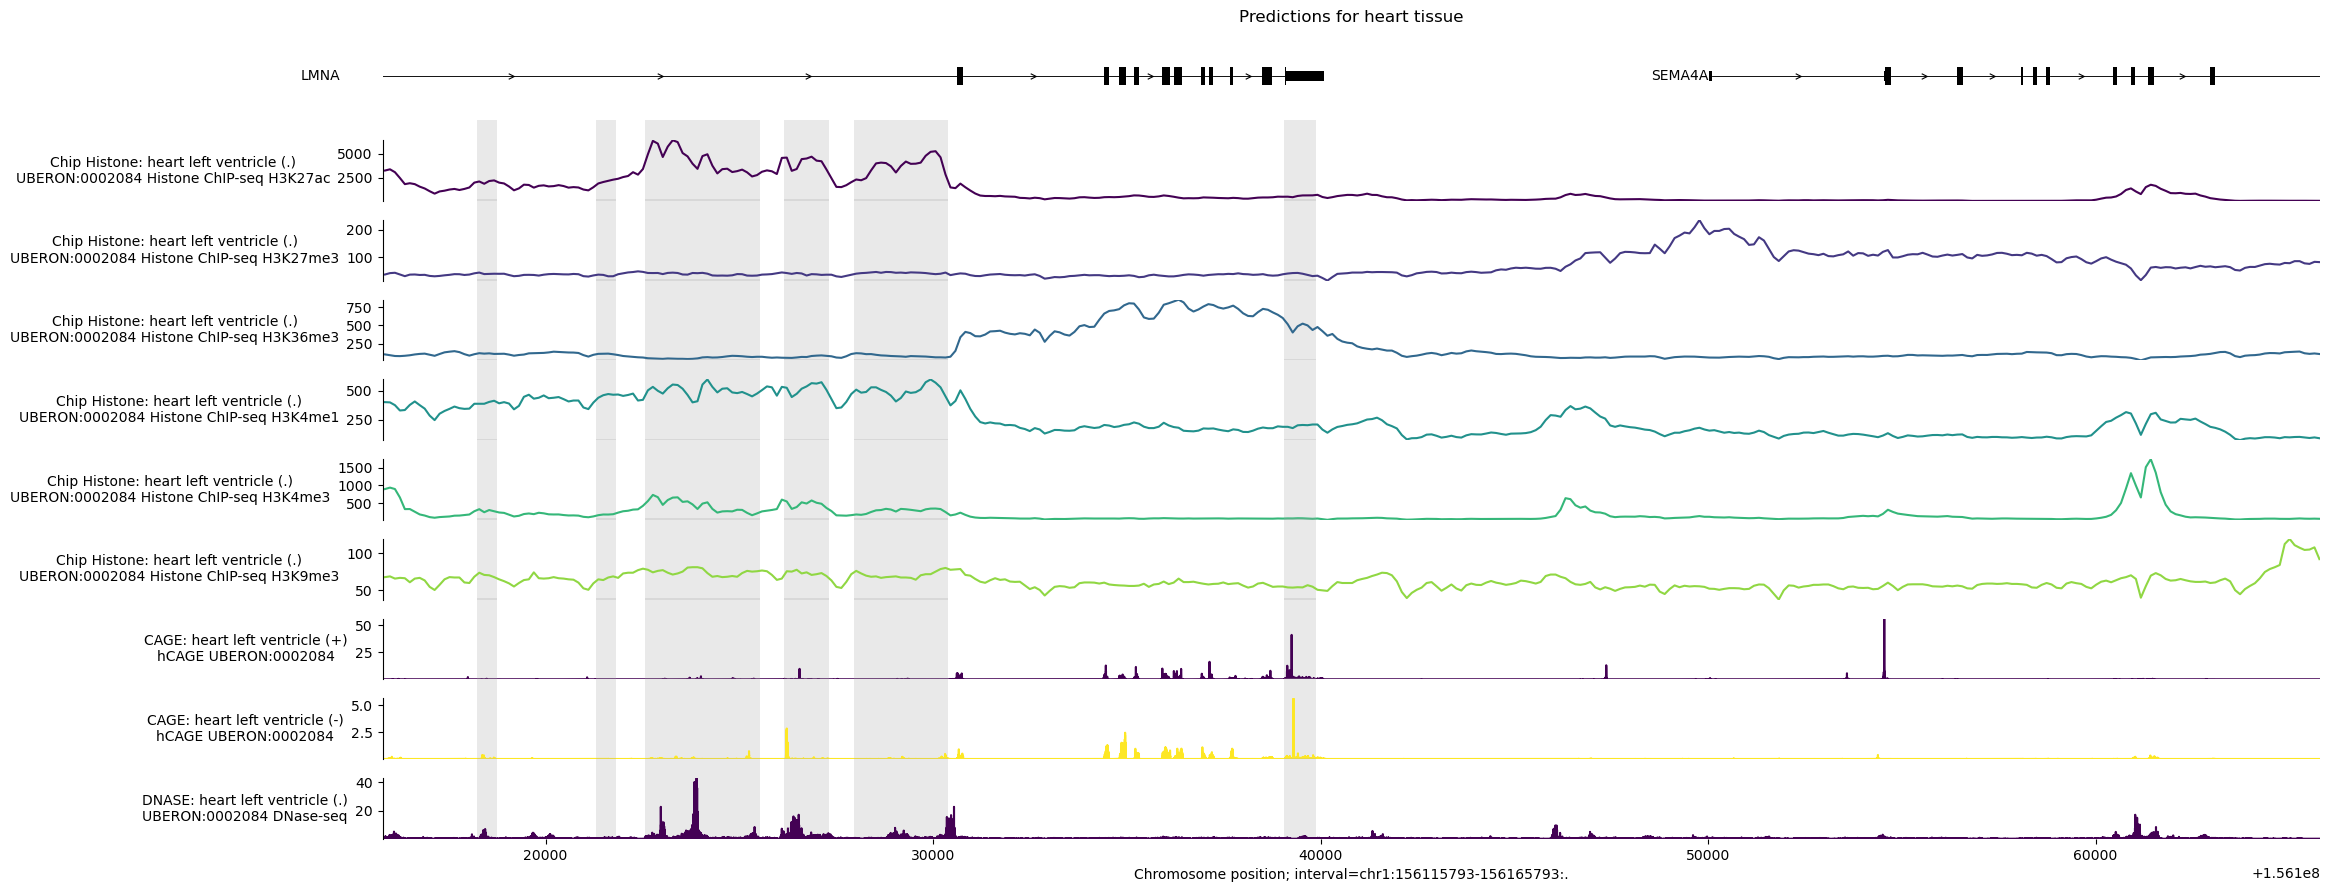

In [67]:

# plot_interval = POST_INTERVAL
plot_interval = genome.Interval('chr1', POST_INTERVAL.start, POST_INTERVAL.start + 50000)

# Build plot.
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),
        # Chip histone.
        plot_components.Tracks(
            tdata=output.chip_histone,
            ylabel_template='Chip Histone: {biosample_name} ({strand})\n{name}',
        ),
        # CAGE.
        plot_components.Tracks(
            tdata=output.cage,
            ylabel_template='CAGE: {biosample_name} ({strand})\n{name}',
        ),
        # dnase
        plot_components.Tracks(
            tdata=output.dnase,
            ylabel_template='DNASE: {biosample_name} ({strand})\n{name}',
        ),

       
    ],
    
     annotations=[
        plot_components.IntervalAnnotation(
            bed_intervals,
            # colors=ccre_colors,
            alpha=0.25,
            use_default_labels=True,   # True if you want cCRE IDs as labels
        ),
    ],
     
    interval=plot_interval,
    fig_width=25,
    title='Predictions for heart tissue',
)

# legend_handles = [
#     mpatches.Patch(color=color, label=key) 
#     for key, color in CCRE_COLORS.items()
# ]

# plot.legend(handles=legend_handles, loc="center left", title="Categories",
#           bbox_to_anchor=(1, 0, 0.5, 1))
# plot.savefig('figs/lmna_predictions_1MB_centered_zoom_5kb_bothsides.png', dpi=300, bbox_inches="tight")


## get info on prediction outputs

In [16]:
def select_tracks(tdata, *, tissue_curie=None, name_contains=None, strand=None):
    """Return a TrackData subset matching metadata filters."""
    if tdata is None:
        return None
    md = tdata.metadata
    mask = pd.Series(True, index=md.index)
    if tissue_curie is not None and "ontology_curie" in md.columns:
        mask &= md["ontology_curie"] == tissue_curie
    if name_contains is not None:
        mask &= md["name"].str.contains(name_contains, case=False, na=False)
    if strand is not None:
        mask &= md["strand"] == strand
    return tdata.filter_tracks(mask.to_numpy())

In [62]:
# ontology_terms = [
#     # 'UBERON:0000948',  # heart
#     # 'UBERON:0002080', # heart RV
#     # 'UBERON:0002084', # heart LV
# ]
# tissue_curie = "UBERON:0000948"
tissue_curie='UBERON:0002084'



for name, tdata in [
    ("dnase", output.dnase),
    # ("atac", output.atac),
    ("chip_histone", output.chip_histone),
    ("chip_tf", output.chip_tf),
    ("cage", output.cage),
]:
    print(f"\n=== {name} ===")
    if tdata is None:
        print("  output field is None (not requested / not returned)")
        continue
    print(f"  total tracks: {tdata.num_tracks}")
    print(tdata.metadata[["name", "strand", "ontology_curie"]].head(10))

    # test your filters
    filtered = select_tracks(tdata, tissue_curie=tissue_curie)
    print(f"  after tissue filter: {filtered.num_tracks if filtered else 0}")

    if name == "chip_histone":
        h3k4 = select_tracks(tdata, tissue_curie=tissue_curie, name_contains="H3K4")
        print(f"  after H3K4 filter: {h3k4.num_tracks if h3k4 else 0}")
        print("  histone names:", tdata.metadata["name"].unique()[:20])


=== dnase ===
  total tracks: 1
                         name strand  ontology_curie
256  UBERON:0002080 DNase-seq      .  UBERON:0002080
  after tissue filter: 0

=== chip_histone ===
  total tracks: 6
                                         name strand  ontology_curie
926   UBERON:0002080 Histone ChIP-seq H3K27ac      .  UBERON:0002080
927  UBERON:0002080 Histone ChIP-seq H3K27me3      .  UBERON:0002080
928  UBERON:0002080 Histone ChIP-seq H3K36me3      .  UBERON:0002080
929   UBERON:0002080 Histone ChIP-seq H3K4me1      .  UBERON:0002080
930   UBERON:0002080 Histone ChIP-seq H3K4me3      .  UBERON:0002080
931   UBERON:0002080 Histone ChIP-seq H3K9me3      .  UBERON:0002080
  after tissue filter: 0
  after H3K4 filter: 0
  histone names: ['UBERON:0002080 Histone ChIP-seq H3K27ac'
 'UBERON:0002080 Histone ChIP-seq H3K27me3'
 'UBERON:0002080 Histone ChIP-seq H3K36me3'
 'UBERON:0002080 Histone ChIP-seq H3K4me1'
 'UBERON:0002080 Histone ChIP-seq H3K4me3'
 'UBERON:0002080 Histone ChIP-s

In [295]:
# print(output.chip_histone.metadata[["name", "strand", "ontology_curie"]])
heart = ontology.from_curie("UBERON:0000948")
output_heart = output.filter_ontology_terms([heart])
output_heart.cage.metadata

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,data_source,nonzero_mean
178,hCAGE UBERON:0000948,+,hCAGE,UBERON:0000948,heart,tissue,fantom,21.734741
451,hCAGE UBERON:0000948,-,hCAGE,UBERON:0000948,heart,tissue,fantom,21.734741


In [56]:
# [t.info['gene_name'] for t in longest_transcripts if t.strand == '+']

# define candidate regulatory regions

In [21]:
# calculate z-score 
def zscore(x):
    mu, sd = x.mean(), x.std()
    return (x - mu) / sd if sd > 0 else x * 0

- Promoter-like signatures (promoter) must fall within 200 bp of a TSS and have high chromatin accessibility and H3K4me3 signals.
- TSS-proximal enhancer-like signatures (proximal enhancer) have high chromatin accessibility and *H3K27ac* signals and are within 2 kb of an annotated TSS. If they are within 200 bp of a TSS, they must also have low H3K4me3 signal.
- TSS-distal enhancer-like signatures (distal enhancer) have high chromatin accessibility and *H3K27ac* signals and are farther than 2 kb from an annotated TSS.
- Chromatin accessibility + H3K4me3 (CA-H3K4me3) have high chromatin accessibility and H3K4me3 signals but low *H3K27ac* signals and do not fall within 200 bp of a TSS.
- Chromatin accessibility + CTCF (CA-CTCF) have high chromatin accessibility and CTCF signals but low H3K4me3 and *H3K27ac* signals.
- Chromatin accessibility + transcription factor (CA-TF) have high chromatin accessibility, low H3K4me3, *H3K27ac*, and CTCF signals, and are bound by a transcription factor.
- Chromatin accessibility (CA) have high chromatin accessibility and low H3K4me3, *H3K27ac*, and CTCF signals.
- Transcription factor (TF) have low chromatin accessibility, low H3K4me3, *H3K27ac*, and CTCF signals and are bound by a transcription factor.

https://github.com/weng-lab/ENCODE-cCREs/tree/master/Version-4/cCRE-Pipeline

chip histone values
- 0   UBERON:0002080 Histone ChIP-seq H3K27ac (enriched at enhancers)
- 1  UBERON:0002080 Histone ChIP-seq H3K27me3 (represses transcription)
- 2  UBERON:0002080 Histone ChIP-seq H3K36me3 (active transcription)
- 3   UBERON:0002080 Histone ChIP-seq H3K4me1 (enriched at enhancers)
- 4   UBERON:0002080 Histone ChIP-seq H3K4me3 (enriched at promoters)
- 5   UBERON:0002080 Histone ChIP-seq H3K9me3 (enriched at promoters and enhancers)

In [72]:
# think of array values as sideways (vertical axis is sequence position)
output.chip_histone.values

array([[3248.  ,   35.75,  107.  ,  400.  ,  900.  ,   67.5 ],
       [3376.  ,   40.75,   95.5 ,  398.  ,  940.  ,   68.5 ],
       [3072.  ,   42.  ,   85.5 ,  374.  ,  900.  ,   65.5 ],
       ...,
       [  85.5 ,  169.  ,   56.5 ,  217.  ,  158.  ,   70.  ],
       [  71.5 ,  154.  ,   56.25,  167.  ,   97.5 ,   64.5 ],
       [  63.25,  157.  ,   59.  ,  132.  ,   79.  ,   59.5 ]],
      shape=(8192, 6), dtype=float32)

In [14]:







# collapse tracks to 1D profile
def collapse_tracks(tdata, how="max"):
    """Collapse (bins, tracks) -> (bins,) signal."""
    if tdata is None or tdata.num_tracks == 0:
        return None
    vals = tdata.values
    if how == "max":
        return vals.max(axis=1)
    if how == "mean":
        return vals.mean(axis=1)
    raise ValueError(how)





# combine tracks per modality based on max z score out of all of the tracks
def combined_regulatory_profile(output, tissue_curie="UBERON:0000948"):
    profiles = []

    dnase = select_tracks(output.dnase, tissue_curie=tissue_curie)
    if dnase is not None:
        profiles.append(zscore(collapse_tracks(dnase, "max")))
        print("appending dnase track")

    atac = select_tracks(output.atac, tissue_curie=tissue_curie)
    if atac is not None:
        profiles.append(zscore(collapse_tracks(atac, "max")))
        print("appending atac track")

    h3k4me3 = select_tracks(
        output.chip_histone,
        tissue_curie=tissue_curie,
        name_contains="K4",
    )
    if h3k4me3 is not None:
        profiles.append(zscore(collapse_tracks(h3k4me3, "max")))
        print("appending h3k4me3 track")

    if not profiles:
        raise ValueError("No tracks matched filters")

    stacked = np.stack(profiles, axis=1)
    return stacked.max(axis=1)   # or .mean(axis=1) for softer consensus


# define threshold of "high scoring" as default 95th percentile
def threshold_bins(signal, method="percentile", value=95):
    if method == "percentile":
        cutoff = np.percentile(signal, value)
    elif method == "std":
        cutoff = signal.mean() + value * signal.std()
    else:
        cutoff = value
    return signal >= cutoff, cutoff


# convert continuous high scoring bins into one interval
def bins_to_intervals(signal, mask, interval, resolution):
    """Turn a boolean mask over bins into merged genomic intervals."""
    regions = []
    in_region = False
    start_bin = None

    for i, is_high in enumerate(mask):
        if is_high and not in_region:
            start_bin = i
            in_region = True
        elif not is_high and in_region:
            regions.append((start_bin, i))
            in_region = False
    if in_region:
        regions.append((start_bin, len(mask)))

    intervals = []
    for b0, b1 in regions:
        start = interval.start + b0 * resolution
        end = interval.start + b1 * resolution
        intervals.append(genome.Interval(interval.chromosome, start, end))
    return intervals


# merge intervals that are within gap# of bp 
def merge_nearby(intervals, gap=150):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x.start)
    merged = [intervals[0]]
    for iv in intervals[1:]:
        prev = merged[-1]
        if iv.start - prev.end <= gap:
            merged[-1] = genome.Interval(
                prev.chromosome, prev.start, max(prev.end, iv.end)
            )
        else:
            merged.append(iv)
    return merged


# add peak scores
def annotate_peak_scores(intervals, signal, interval, resolution):
    for iv in intervals:
        b0 = (iv.start - interval.start) // resolution
        b1 = (iv.end - interval.start) // resolution
        iv.info["max_signal"] = float(signal[b0:b1].max())
        iv.info["mean_signal"] = float(signal[b0:b1].mean())
    return sorted(intervals, key=lambda x: x.info["max_signal"], reverse=True)





## based on all modalities (taking max z-score)

In [24]:
def isolate_high_regulatory_regions(
    output,
    *,
    tissue_curie="UBERON:0000948",
    modalities=("dnase", "cage", "chip_histone"),
    histone_mark="H3K4",
    collapse="max",
    resolution_bp=1,
    threshold_method="percentile",
    threshold_value=95,
    min_width_bp=500,
    merge_gap_bp=200,):

    
    profiles = []
    anchor_interval = None
    anchor_resolution = resolution_bp

    def process(tdata):
        nonlocal anchor_interval
        if tdata is None:
            return
        tdata = tdata.change_resolution(resolution_bp)
        anchor_interval = tdata.interval
        profiles.append(zscore(collapse_tracks(tdata, collapse)))

    modality_map = {
        "dnase": select_tracks(output.dnase, tissue_curie=tissue_curie),
        "atac": select_tracks(output.atac, tissue_curie=tissue_curie),
        "chip_histone": select_tracks(
            output.chip_histone,
            tissue_curie=tissue_curie,
            name_contains=histone_mark,
        ),
        "chip_tf": select_tracks(output.chip_tf, tissue_curie=tissue_curie),
        "cage": select_tracks(output.cage, tissue_curie=tissue_curie, strand='+'), # only pos strand b/c LMNA is on + strand only
    }

    for m in modalities:
        print(m)
        process(modality_map[m])

    print(profiles)

    # gets max score across all profiles
    signal = np.stack(profiles, axis=1).max(axis=1)
    print(signal[:10])
    mask, cutoff = threshold_bins(signal, threshold_method, threshold_value)

    intervals = bins_to_intervals(signal, mask, anchor_interval, anchor_resolution)
    
    intervals = [iv for iv in intervals if iv.width >= min_width_bp]

    # merge intervals that are within merge_gap_bp range of each other
    intervals = merge_nearby(intervals, merge_gap_bp)

    # calculate peak scores for intervals
    intervals = annotate_peak_scores(intervals, signal, anchor_interval, anchor_resolution)

    return {
        "intervals": intervals,
        "signal": signal,
        "cutoff": cutoff,
        "resolution": anchor_resolution,
        "anchor_interval": anchor_interval,
    }


## based on single modality at a time

In [16]:
def isolate_high_regulatory_regions_singlemod(
    output,
    *,
    tissue_curie="UBERON:0000948",
    modalities=["dnase"],
    histone_mark="H3K4",
    collapse="max",
    resolution_bp=1,
    threshold_method="percentile",
    threshold_value=95,
    min_width_bp=500,
    merge_gap_bp=200,):

    
    profiles = []
    anchor_interval = None
    anchor_resolution = resolution_bp

    def process(tdata):
        nonlocal anchor_interval
        if tdata is None:
            return
        tdata = tdata.change_resolution(resolution_bp)
        anchor_interval = tdata.interval
        profiles.append(zscore(collapse_tracks(tdata, collapse)))

    modality_map = {
        "dnase": select_tracks(output.dnase, tissue_curie=tissue_curie),
        "atac": select_tracks(output.atac, tissue_curie=tissue_curie),
        "chip_histone": select_tracks(
            output.chip_histone,
            tissue_curie=tissue_curie,
            name_contains=histone_mark,
        ),
        "chip_tf": select_tracks(output.chip_tf, tissue_curie=tissue_curie),
        "cage": select_tracks(output.cage, tissue_curie=tissue_curie, strand='+'),
    }

    for m in range(len(modalities)):
        modality = modalities[m]
        print(modality)
        process(modality_map[modality])

    print(profiles)

    # gets max score across all profiles
    signal = np.stack(profiles, axis=1).max(axis=1)
    print(signal[:10])
    mask, cutoff = threshold_bins(signal, threshold_method, threshold_value)

    intervals = bins_to_intervals(signal, mask, anchor_interval, anchor_resolution)
    
    intervals = [iv for iv in intervals if iv.width >= min_width_bp]

    # merge intervals that are within merge_gap_bp range of each other
    intervals = merge_nearby(intervals, merge_gap_bp)

    # calculate peak scores for intervals
    intervals = annotate_peak_scores(intervals, signal, anchor_interval, anchor_resolution)

    return {
        "intervals": intervals,
        "signal": signal,
        "cutoff": cutoff,
        "resolution": anchor_resolution,
        "anchor_interval": anchor_interval,
    }

In [17]:
modality = 'dnase'
lmna_context = 'post'


result = isolate_high_regulatory_regions(output, modalities = [modality])
high_regions = result["intervals"]

print(high_regions)

# top 10 highest scoring regions
for iv in high_regions[:10]:
    print(iv, iv.info)

dnase
[array([ 0.4086206 ,  1.1576222 ,  2.054818  , ...,  0.00861484,
       -0.15458788, -0.1768029 ], shape=(8192,), dtype=float32)]
[ 0.4086206   1.1576222   2.054818    0.84420437  0.21227485  0.21884839
 -0.06323572 -0.15692897 -0.10109066 -0.16232923]
[Interval(chromosome='chr1', start=156337873, end=156339025, strand='.', name=''), Interval(chromosome='chr1', start=156766801, end=156767953, strand='.', name=''), Interval(chromosome='chr1', start=156740817, end=156741585, strand='.', name=''), Interval(chromosome='chr1', start=156282449, end=156283217, strand='.', name=''), Interval(chromosome='chr1', start=156193617, end=156194385, strand='.', name=''), Interval(chromosome='chr1', start=156456401, end=156457809, strand='.', name=''), Interval(chromosome='chr1', start=156504785, end=156505681, strand='.', name=''), Interval(chromosome='chr1', start=156499665, end=156501841, strand='.', name=''), Interval(chromosome='chr1', start=156728273, end=156729297, strand='.', name=''), In

In [18]:
# make bed formatted df of predicted regions
# chrom / chromStart / chromEnd / name / score / strand 


output_df = pd.DataFrame([
    {
        "chrom": iv.chromosome,
        "start": iv.start,
        "end": iv.end,
        "name": f"pred_reg_{lmna_context}_{modality}_{i}",
        "score": iv.info.get("max_signal"),
    }
    for i, iv in enumerate(result["intervals"])
])

# output_df.to_csv(f"outputs/predicted_reg_{lmna_context}_{modality}_combinedtracks.bed", index = False, sep='\t')

## isolate regulatory regions based on individual modality peaks

In [25]:
modalities=["dnase", "cage", "chip_histone"]

df_list = []

for i in range(len(modalities)):
    modality = modalities[i]
    # print(modality)
    result = isolate_high_regulatory_regions(output, modalities = [modality])
    output_df = pd.DataFrame([
    {
        "chrom": iv.chromosome,
        "start": iv.start,
        "end": iv.end,
        "name": f"pred_reg_{lmna_context}_{modality}_{i}",
        "score": iv.info.get("max_signal"),
    }
    for i, iv in enumerate(result["intervals"])
    ])
    df_list.append(output_df)


pred_regions_df = pd.concat(df_list)
pred_regions_df

pred_regions_df.to_csv(f"outputs/predicted_reg_regions_{lmna_context}_combinedtracks.bed", index = False, sep='\t')

dnase
[array([ 0.12213761, -0.04868603,  0.33780247, ..., -0.13569932,
        0.10291994, -0.097264  ], shape=(1048576,), dtype=float32)]
[ 0.12213761 -0.04868603  0.33780247  0.03352284  0.11146113  0.22890237
  0.5961732   0.30577302 -0.13062799  0.5278438 ]
cage
[array([-0.01056608, -0.01059868, -0.00949054, ..., -0.01479696,
       -0.01442419, -0.01440789], shape=(1048576,), dtype=float32)]
[-0.01056608 -0.01059868 -0.00949054 -0.0092624  -0.00906684 -0.01024016
 -0.01046831 -0.00720909 -0.01147867 -0.01340976]
chip_histone
[array([ 2.7828596 ,  2.7828596 ,  2.7828596 , ..., -0.10050758,
       -0.10050758, -0.10050758], shape=(1048576,), dtype=float32)]
[2.7828596 2.7828596 2.7828596 2.7828596 2.7828596 2.7828596 2.7828596
 2.7828596 2.7828596 2.7828596]
